# 03 Machine Learning Models

This notebook is executed and includes outputs plus interpretation notes.

## Goal
Evaluate whether temporal, national weather, sectoral, spatial, and OSB exposure variables can classify incident severity. The target is severity: low, medium, high.

In [1]:
from pathlib import Path
import sys, json
import pandas as pd
import numpy as np
sys.path.append(str(Path.cwd().parent))

from src.analysis import run_ml
clean = pd.read_excel('../data/processed/kmo_incidents_clean.xlsx')
istanbul = pd.read_excel('../data/processed/istanbul_enriched.xlsx')
comparison = pd.read_excel('../reports/model_comparison.xlsx')
comparison

,model,cv_f1_macro_mean,cv_f1_macro_std,test_f1_macro,test_accuracy
0,Random Forest,0.495501,0.022466,0.527755,0.905318
1,XGBoost,0.442158,0.030951,0.478000,0.913100
2,Logistic Regression,0.419717,0.014833,0.425501,0.783398


In [2]:
clean['severity'].value_counts().rename_axis('severity').reset_index(name='count')

,severity,count
0,low,3490
1,medium,227
2,high,135


### Class Balance Interpretation
The target is highly imbalanced: most records are low severity. Therefore macro-F1 is more relevant than accuracy. A high accuracy score can be misleading if the model mostly predicts the majority class.

In [3]:
comparison.sort_values('cv_f1_macro_mean', ascending=False)

,model,cv_f1_macro_mean,cv_f1_macro_std,test_f1_macro,test_accuracy
0,Random Forest,0.495501,0.022466,0.527755,0.905318
1,XGBoost,0.442158,0.030951,0.478000,0.913100
2,Logistic Regression,0.419717,0.014833,0.425501,0.783398


### Model Interpretation
Random Forest performs best in cross-validation, but macro-F1 remains moderate. This suggests the available features capture some structure, especially sector, incident type, OSB exposure, and weak province-day weather context, but severity is still difficult to predict from public report fields alone.

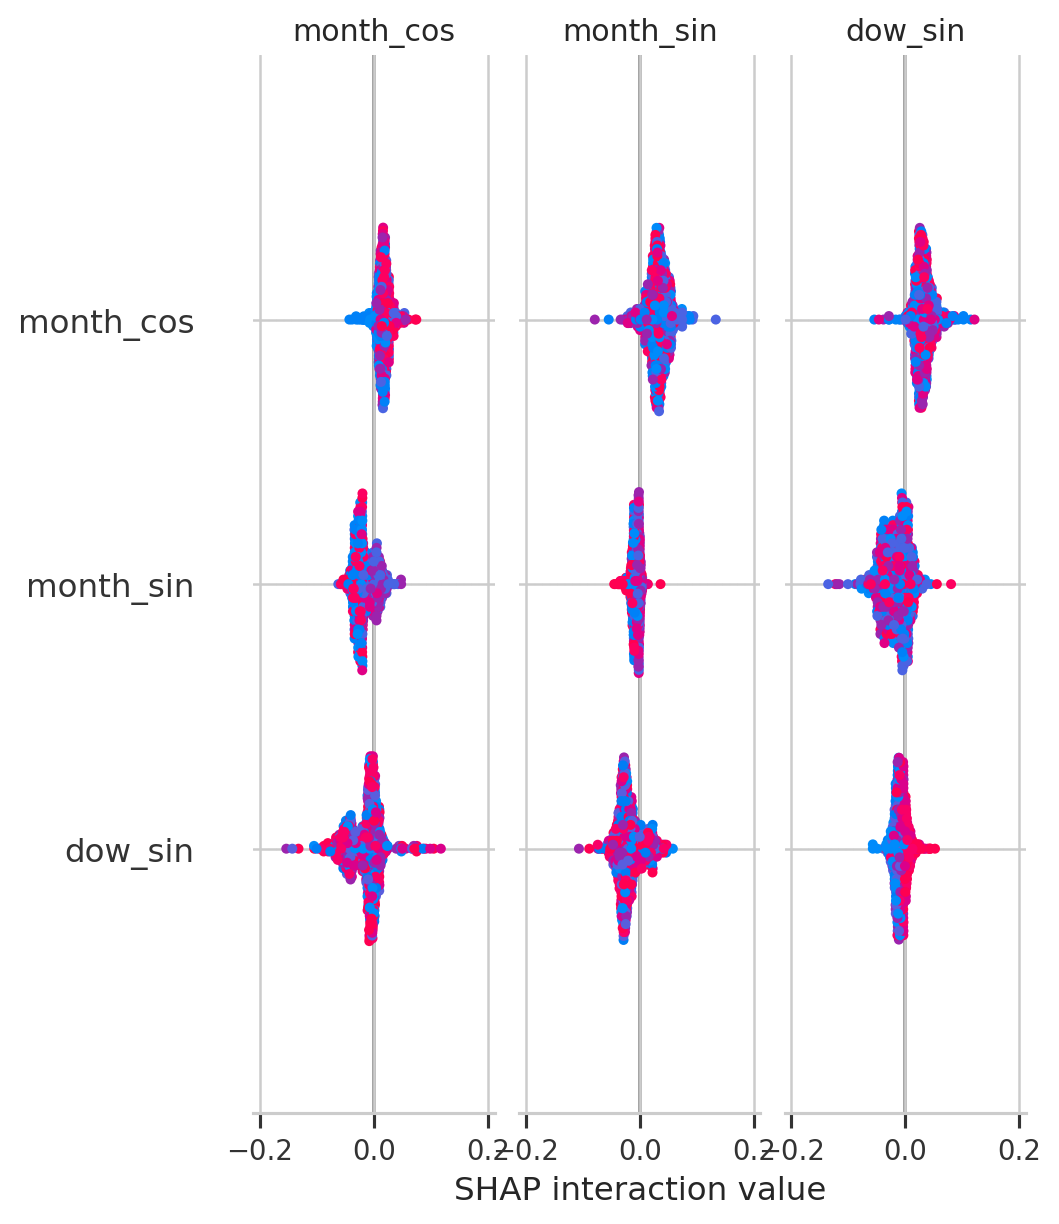

In [4]:
from IPython.display import Image, display
display(Image(filename='../figures/14_shap_summary.png'))

### SHAP Interpretation
The SHAP plot provides a feature-importance view for the best tree-based model. The most useful interpretation is comparative: OSB exposure, sector, incident type, and weather/contextual variables help the model more than pure calendar variables alone. This supports the revised framing around exposure-adjusted national risk rather than only monthly seasonality.